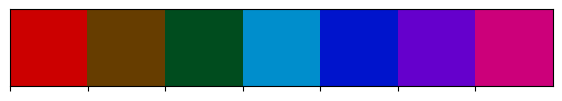

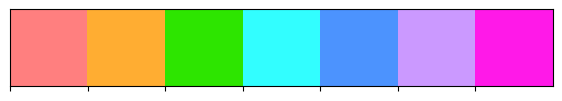

In [1]:
import os
import sys
import torch
import numpy as np
import scipy
import gymnasium as gym
import random
import matplotlib.pylab as plt
import time
SCRIPT_DIR = os.path.dirname(os.path.abspath("..src"))
sys.path.append(os.path.dirname(SCRIPT_DIR))
from src.wrappers.env_wrappers import WallObs, WindowViewObs, ObsToImage, MultiChannel
from src.wrappers.monitor_wrappers import BinaryMonitor, RoomMonitor

from src.policy_analysis import discount_episode_reward, sum_ep_timesteps, set_blind_colors
light_colors, dark_colors = set_blind_colors()

In [2]:
device = "mps:0"
grid_size = [10, 10]
eps_decay = 0.0001
n_mdp_actions = 6
window_size = 11
dryness = 0.05
gamma = 0.99
q_lr = 0.0001
r_lr = 0.0001
timesteps_freq = int(5e5)
n_rows, n_colums = grid_size

In [3]:
def select_action(q_values) -> int:
    """Choose an action from a Q value distribution/ break ties to a random action"""
    indices = np.argwhere(q_values == np.max(q_values))
    return random.choice(indices)[0]

def load_train_reward(dir: str):
    reward_train_all = np.load(dir + "reward_train_all.npy", allow_pickle=True)[()]["seeds_y_axis"]
    reward_train_mean = np.load(dir + "reward_train_mean.npy")
    reward_train_std = np.load(dir + "reward_train_std.npy")
    reward_train_confidence = np.load(dir + "reward_train_confidence.npy")
    return reward_train_all, reward_train_mean, reward_train_std, reward_train_confidence

def confidence_interval(data, confidence=0.95):
    conf = scipy.stats.sem(data) * scipy.stats.t.ppf((1 + confidence) / 2, len(data) - 1)
    return conf

def confidence_interval_2d(data: np.ndarray, confidence: float=0.95):
    confds = []
    for j in range(data.shape[1]):
        k = confidence_interval(data[:, j], confidence)
        confds.append(k)
    return np.array(confds)

In [19]:
env = gym.make("gym_monitor/Plants-Watering-v1",
    grid_size=grid_size,
    n_plants=8,
    plants_dryness_prob=dryness,
    dry_difference=0.5,
    agent_start_pos=None,
    max_episode_steps=100,
    render_mode = "human",
    add_new_plants=True,
    add_more_plants=False,
    )

env = WallObs(env, grid_size=grid_size, n_walls=5)
env = WindowViewObs(env, window_size=window_size)
env = MultiChannel(env)
# env = BinaryMonitor(env, full_monitor=False, monitor_cost=0.2)
env = RoomMonitor(env, full_monitor=False, monitor_cost=0.0, monitor_column_ind=5)

/Users/montaser/miniconda3/envs/mmdp/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:29: UserWarning: WARN: It seems a Box observation space is an image but the `dtype` is not `np.uint8`, actual type: float64. If the Box observation space is not an image, we recommend flattening the observation to have only a 1D vector.
  logger.warn(
/Users/montaser/miniconda3/envs/mmdp/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:34: UserWarning: WARN: It seems a Box observation space is an image but the lower and upper bounds are not [0, 255]. Actual lower bound: 0.0, upper bound: 1.0. Generally, CNN policies assume observations are within that range, so you may encounter an issue if the observation values are not.
  logger.warn(


## Binary Monitor: Frequency of action ask to be monitored

In [5]:
n_checks = 31
n_ep = 10
n_seeds = 10

dir_str = "../general_models/Plants/reward_model/{}_{}_channel/dry_{}/window_{}/eps_decay_{}/q_lr_{}/reward_lr_{}".format(
    n_rows, n_colums, dryness, window_size, eps_decay, q_lr, r_lr)

seeds_monitor_frequency = -1 * np.ones((n_seeds, n_checks, n_ep))
for seed in range(n_seeds):
    for check in range(n_checks):
        q_model = torch.load(dir_str + "/checkpoints_{}/q_network_{}".format(check, seed), map_location=torch.device(device))
        for episode in range(n_ep):
            ask_action = 0
            s, _ = env.reset()
            total_r, timestep, spill, cactus, water_plant = 0, 0, 0, 0, 0
            done = False
            actions, mdp_s, mon_s = [], [], []
            while timestep < 100 and not done:
                mdp_obs = torch.tensor(s["mdp"], dtype=torch.float32, device=device).unsqueeze(0)
                mdp_s.append(mdp_obs)
                with torch.no_grad():
                    q_values = q_model(mdp_obs)
                action = select_action(q_values.cpu().numpy().squeeze())
                actions.append(action)
                s, r, done, _, info = env.step({"mdp": action % n_mdp_actions, "monitor": action // n_mdp_actions})
                if action // n_mdp_actions == 1:
                    ask_action += 1
                reward = info["mdp_reward"] + r["monitor"]
                total_r += reward * (gamma**timestep)
                timestep += 1
            seeds_monitor_frequency[seed, check, episode] = ask_action
env.close()
np.save(dir_str + "/training_frequency_ask_moniotred_full", seeds_monitor_frequency)

/var/folders/wr/tm6dhxps7gnfznj02g89rcx40000gn/T/ipykernel_69930/1767099922.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  q_model = torch.load(dir_str + "/checkpoints

In [12]:
reward_frq = np.load("../general_models/Plants/reward_model/10_10_channel/dry_0.05/window_11/eps_decay_0.0001/q_lr_0.0001/reward_lr_0.0001/training_frequency_ask_moniotred.npy")
ignore_frq = np.load("../general_models/Plants/ignore/10_10_channel/dry_0.05/window_11/eps_decay_0.0001/q_lr_0.0001/reward_lr_0.0001/training_frequency_ask_moniotred.npy")
zero_frq = np.load("../general_models/Plants/zero_reward/10_10_channel/dry_0.05/window_11/eps_decay_0.0001/q_lr_0.0001/reward_lr_0.0001/training_frequency_ask_moniotred.npy")

n_checkpoints = 21
reward_means, reward_conf = np.zeros(n_checkpoints), np.zeros(n_checkpoints)
ignore_means, ignore_conf = np.zeros(n_checkpoints), np.zeros(n_checkpoints)
zero_means, zero_conf = np.zeros(n_checkpoints), np.zeros(n_checkpoints)
for i in range(n_checkpoints):
    reward_means[i] = np.mean(reward_frq[:, i, :]) / 100
    reward_conf[i] = confidence_interval(np.mean(reward_frq[:, i, :], 0)) / 100

    ignore_means[i] = np.mean(ignore_frq[:, i, :]) / 100
    ignore_conf[i] = confidence_interval(np.mean(ignore_frq[:, i, :], 0)) / 100

    zero_means[i] = np.mean(zero_frq[:, i, :]) / 100
    zero_conf[i] = confidence_interval(np.mean(zero_frq[:, i, :], 0)) / 100

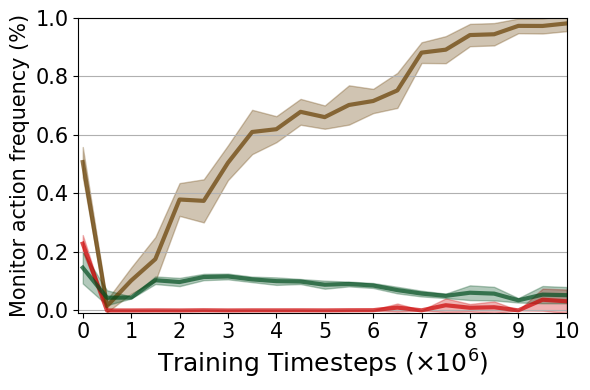

In [14]:
fig = plt.figure(figsize=(6, 4))
count = 0

plt.xlabel(r"Training Timesteps $(\times10^6)$", fontsize=18)
plt.ylabel("Monitor action frequency (%)", fontsize=15)

plt.plot(np.arange(n_checkpoints) * timesteps_freq, reward_means, lw=3,  c=dark_colors[count], alpha=0.7, label="Reward model")
plt.fill_between(np.arange(n_checkpoints) * timesteps_freq, reward_means - reward_conf, reward_means + reward_conf, color=dark_colors[count], alpha=0.3)
count += 1

plt.plot(np.arange(n_checkpoints) * timesteps_freq, ignore_means, lw=3,  c=dark_colors[count], alpha=0.7, label=r"$\bot = 0$")
plt.fill_between(np.arange(n_checkpoints) * timesteps_freq, ignore_means - ignore_conf, ignore_means + ignore_conf, color=dark_colors[count], alpha=0.3)
count += 1

plt.plot(np.arange(n_checkpoints) * timesteps_freq, zero_means, lw=3,  c=dark_colors[count], alpha=0.7, label="Ignore")
plt.fill_between(np.arange(n_checkpoints) * timesteps_freq, zero_means - zero_conf, zero_means + zero_conf, color=dark_colors[count], alpha=0.3)
count += 1
x_legend = np.arange(0, n_checkpoints + 2, 2) * 0.5
plt.xticks(np.arange(0, n_checkpoints + 2, 2) * timesteps_freq, x_legend.astype(int), fontsize=15)
plt.yticks(fontsize=15)
plt.grid(axis="y")
plt.ylim(-0.007, 1)
plt.xlim(-90000, 1e7)
plt.tight_layout()
dir = "../general_models/Plants/reward_model/10_10_channel/dry_0.05/window_11/eps_decay_0.0001/"
# plt.savefig(dir + "monitor_action_frequency_baselines_no_legend.pdf", dpi=300)

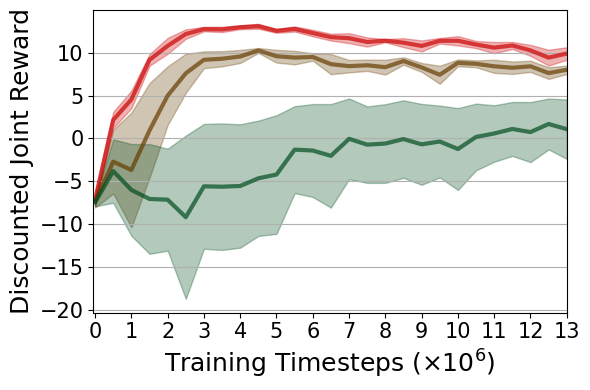

In [8]:
timestep_clip = 13e6
fig = plt.figure(figsize=(6, 4))
count = 0
for base in ["reward_model", "zero_reward", "ignore"]:
    main_dir = "../general_models/Plants/{}/{}_{}_channel/dry_{}/window_{}/eps_decay_{}".format(
        base, n_rows, n_colums, dryness, window_size, 0.0001)
    log_dir = main_dir + "/q_lr_{}/reward_lr_{}/".format(q_lr, r_lr)
    _, mean_train, _, conf_train = load_train_reward(log_dir)
    plt.plot(np.arange(len(mean_train)) * timesteps_freq, mean_train, lw=3,  c=dark_colors[count], alpha=0.7, label=base)
    plt.fill_between(np.arange(len(mean_train)) * timesteps_freq, mean_train - conf_train, mean_train + conf_train, color=dark_colors[count], alpha=0.3)
    count += 1


plt.xlabel(r"Training Timesteps $(\times 10^6)$", fontsize=18)
plt.ylabel("Discounted Joint Reward", fontsize=18)

x_legend = np.arange(0, timestep_clip + 1e6, 2 * timesteps_freq) / 1e6
plt.xticks(np.arange(0, timestep_clip + 1e6, 2 * timesteps_freq), x_legend.astype(int), fontsize=15)
plt.xlim(-50000, timestep_clip)
plt.yticks(fontsize=15)
plt.grid(axis="y")
# plt.legend(fontsize=12)
plt.tight_layout()
dir = "../general_models/Plants/reward_model/10_10_channel/dry_0.05/window_11/eps_decay_0.0001/"
# fig.savefig(dir + "/binary_training_curve_confidence_long.pdf", dpi=300)    

## Half-room Monitor

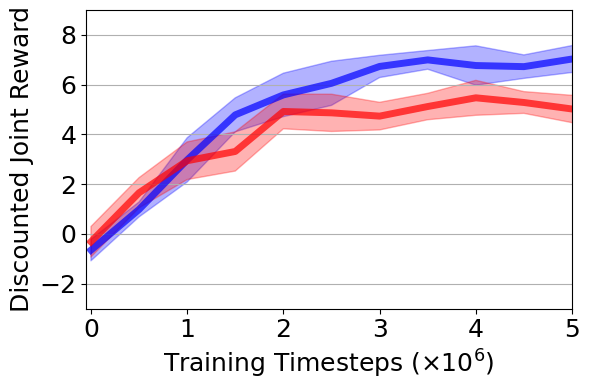

In [37]:
n_seeds = 10
ep_max_length = 100
ep_window = 10

timestep_clip = 5e6

discount = np.array([gamma**i for i in range(ep_max_length)])
room_main_dir = "../general_models/Plants/reward_model/{}_{}_channel/dry_{}/room/window_{}/eps_decay_0.0001/".format(
    n_rows, n_colums, dryness, window_size)
room_log_dir = room_main_dir + "/q_lr_{}/reward_lr_{}/".format(0.0001, 0.0001)

cut_indx = 5 if n_rows == 10 else 3
cut_indx_1 = int(cut_indx * 2)

fig = plt.figure(figsize=(6, 4))
one_seeds, two_seeds, three_seeds = [], [], []
for seed in range(n_seeds):
    agent_pos = np.load(room_log_dir + "/agent_locations_{}.npy".format(seed))
    train_reward = np.load(room_log_dir + "training_joint_reward_{}.npy".format(seed), allow_pickle=True)[()]
    reward_1, reward_2, reward_3 = [], [], []
    
    for ep_train in range(len(agent_pos)):
        ones = np.squeeze(np.argwhere(agent_pos[ep_train, : , 1] < cut_indx))
        twos = np.squeeze(np.argwhere((agent_pos[ep_train, : , 1] > cut_indx) & (agent_pos[ep_train, : , 1] < cut_indx_1)))
    
        reward_1.append(np.sum(np.array(train_reward[ep_train])[ones] * discount[ones]))
        reward_2.append(np.sum(np.array(train_reward[ep_train])[twos] * discount[twos]))
    
    ep_length = ep_max_length * np.ones(len(train_reward))
    ep_timesteps_sum = sum_ep_timesteps(ep_length)
    x_axis = np.arange(ep_length[0], int(ep_timesteps_sum[-1]), timesteps_freq)
    y_axis_1, y_axis_2, y_axis_3 = [], [], []
    for timestep in range(int(ep_length[0]), int(ep_timesteps_sum[-1]), timesteps_freq):
        ind = np.where(ep_timesteps_sum > timestep)[0][0]
        value_1 = np.mean(reward_1[ind - ep_window: ind]) if ind > ep_window else reward_1[ind]
        value_2 = np.mean(reward_2[ind - ep_window: ind]) if ind > ep_window else reward_2[ind]

        y_axis_1.append(value_1)
        y_axis_2.append(value_2)

    one_seeds.append(y_axis_1)
    two_seeds.append(y_axis_2)
lenghts_1 = [len(l) for l in one_seeds]
lenghts_2 = [len(l) for l in two_seeds]

mean_1 = np.mean(np.array([l[:min(lenghts_1)] for l in one_seeds]), 0)
mean_2 = np.mean(np.array([l[:min(lenghts_2)] for l in two_seeds]), 0)

std_1 = confidence_interval_2d(np.array([l[:min(lenghts_1)] for l in one_seeds]))
std_2 = confidence_interval_2d(np.array([l[:min(lenghts_2)] for l in two_seeds]))

plt.plot(np.arange(len(mean_1)) * timesteps_freq, mean_1, lw=5,  c="b", alpha=0.7, label="Zone 1")
plt.fill_between(np.arange(len(mean_1)) * timesteps_freq, mean_1 - std_1, mean_1 + std_1, color="b", alpha=0.3)

plt.plot(np.arange(len(mean_2)) * timesteps_freq, mean_2, lw=5,  c="r", alpha=0.7, label="Zone 2")
plt.fill_between(np.arange(len(mean_2)) * timesteps_freq, mean_2 - std_2, mean_2 + std_2, color="r", alpha=0.3)

plt.xlabel(r"Training Timesteps ($\times10^{6}$)", fontsize=18)
plt.ylabel("Discounted Joint Reward", fontsize=18)

x_legend = np.arange(0, timestep_clip + 1e6, 2 * timesteps_freq) / 1e6
plt.xticks(np.arange(0, timestep_clip + 1e6, 2 * timesteps_freq), x_legend.astype(int), fontsize=15)
plt.yticks(fontsize=18) #18
plt.xticks(fontsize=18) #18
plt.xlim(-50000, timestep_clip)
plt.ylim(-3, 9)
plt.grid(axis="y")
plt.tight_layout()
fig.savefig(room_main_dir + "training_reward_per_room_reward_short_no_legend.pdf", dpi=300)

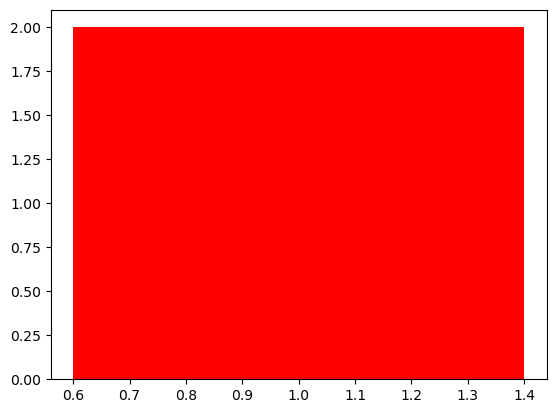

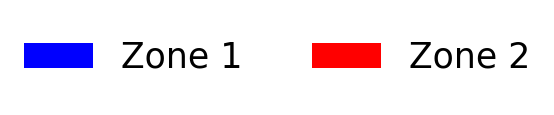

In [16]:
legends = ["Zone 1", "Zone 2"]
f = lambda m,c: plt.bar(1,2, color=c)[0]
colors = ["b", "r"]
handles = [f("s", colors[i]) for i in range(2)]
fig = plt.figure(figsize=(5, 1.25))
fig.legend(handles, legends, fontsize=25, ncol=6, loc='center', frameon=False)
fig.gca().set_axis_off()
plt.tight_layout()
# fig.savefig("../general_models/Plants/reward_model/10_10_channel/dry_0.05/room/window_11/" + "legend.pdf", dpi=300,)

## Baslines

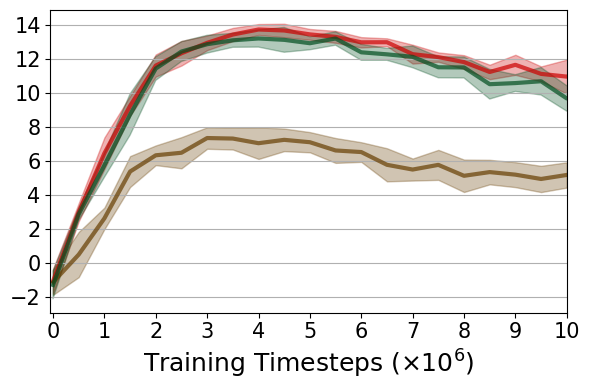

In [17]:
timestep_clip = 10e6
fig = plt.figure(figsize=(6, 4))
count = 0
for base in ["reward_model", "zero_reward", "ignore"]:
    main_dir = "../general_models/Plants/{}/{}_{}_channel/dry_{}/room/window_{}/eps_decay_{}".format(
        base, n_rows, n_colums, dryness, window_size, 0.0001)
    log_dir = main_dir + "/q_lr_{}/reward_lr_{}/".format(q_lr, r_lr)
    seed_train, mean_train, _, conf_train = load_train_reward(log_dir)
    # for seed_tr in seed_train:
    #     plt.plot(np.arange(len(seed_tr)) * timesteps_freq, seed_tr, lw=0.5,  c=dark_colors[count])
    plt.plot(np.arange(len(mean_train)) * timesteps_freq, mean_train, lw=3,  c=dark_colors[count], alpha=0.7, label=base)
    plt.fill_between(np.arange(len(mean_train)) * timesteps_freq, mean_train - conf_train, mean_train + conf_train, color=dark_colors[count], alpha=0.3)
    count += 1


plt.xlabel(r"Training Timesteps $(\times 10^6)$", fontsize=18)
# plt.ylabel("Discounted Joint Reward", fontsize=18)

x_legend = np.arange(0, timestep_clip + 1e6, 2 * timesteps_freq) / 1e6
plt.xticks(np.arange(0, timestep_clip + 1e6, 2 * timesteps_freq), x_legend.astype(int), fontsize=15)
plt.xlim(-50000, timestep_clip)
plt.yticks(fontsize=15)
plt.grid(axis="y")
# plt.legend(fontsize=12)
plt.tight_layout()
dir = "../general_models/Plants/reward_model/10_10_channel/dry_0.05/room/window_11/eps_decay_0.0001/"
# fig.savefig(dir + "/room_training_curve_confidence_long.pdf", dpi=300)    

## Cacti-room Monitor

In [46]:
n_seeds = 10
ep_max_length = 100
ep_window = 10

timestep_clip = 10e6

discount = np.array([gamma**i for i in range(ep_max_length)])
cacti_main_dir = "../general_models/Plants/reward_model/{}_{}_channel/dry_{}/cacti_room/window_{}/eps_decay_0.0001/".format(
    n_rows, n_colums, dryness, window_size)
cacti_log_dir = cacti_main_dir + "/q_lr_{}/reward_lr_{}/".format(0.0001, 0.0001)
cut_indx = 5 if n_rows == 10 else 3
cut_indx_1 = int(cut_indx * 2)

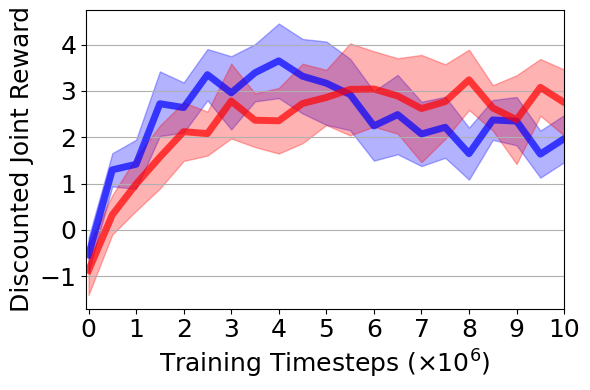

In [27]:
fig = plt.figure(figsize=(6, 4))
one_seeds, two_seeds, three_seeds = [], [], []
for seed in range(n_seeds):
    agent_pos = np.load(cacti_log_dir + "/agent_locations_{}.npy".format(seed))
    train_reward = np.load(cacti_log_dir + "training_joint_reward_{}.npy".format(seed), allow_pickle=True)[()]
    reward_1, reward_2, reward_3 = [], [], []

    limit = min(list(train_reward.keys())[-1], len(agent_pos))
    for ep_train in range(limit):
    # for ep_train in range(len(agent_pos)):
        ones = np.squeeze(np.argwhere(agent_pos[ep_train, : , 1] < cut_indx))
        twos = np.squeeze(np.argwhere((agent_pos[ep_train, : , 1] > cut_indx) & (agent_pos[ep_train, : , 1] < cut_indx_1)))
    
        reward_1.append(np.sum(np.array(train_reward[ep_train])[ones] * discount[ones]))
        reward_2.append(np.sum(np.array(train_reward[ep_train])[twos] * discount[twos]))
    
    ep_length = ep_max_length * np.ones(len(train_reward))
    ep_timesteps_sum = sum_ep_timesteps(ep_length)
    x_axis = np.arange(ep_length[0], int(ep_timesteps_sum[-1]), timesteps_freq)
    y_axis_1, y_axis_2, y_axis_3 = [], [], []
    for timestep in range(int(ep_length[0]), int(ep_timesteps_sum[-1]), timesteps_freq):
        ind = np.where(ep_timesteps_sum > timestep)[0][0]
        value_1 = np.mean(reward_1[ind - ep_window: ind]) if ind > ep_window else reward_1[ind]
        value_2 = np.mean(reward_2[ind - ep_window: ind]) if ind > ep_window else reward_2[ind]

        y_axis_1.append(value_1)
        y_axis_2.append(value_2)

    one_seeds.append(y_axis_1)
    two_seeds.append(y_axis_2)
lenghts_1 = [len(l) for l in one_seeds]
lenghts_2 = [len(l) for l in two_seeds]

mean_1 = np.mean(np.array([l[:min(lenghts_1)] for l in one_seeds]), 0)
mean_2 = np.mean(np.array([l[:min(lenghts_2)] for l in two_seeds]), 0)

std_1 = confidence_interval_2d(np.array([l[:min(lenghts_1)] for l in one_seeds]))
std_2 = confidence_interval_2d(np.array([l[:min(lenghts_2)] for l in two_seeds]))

plt.plot(np.arange(len(mean_1)) * timesteps_freq, mean_1, lw=5,  c="b", alpha=0.7, label="Zone 1")
plt.fill_between(np.arange(len(mean_1)) * timesteps_freq, mean_1 - std_1, mean_1 + std_1, color="b", alpha=0.3)

plt.plot(np.arange(len(mean_2)) * timesteps_freq, mean_2, lw=5,  c="r", alpha=0.7, label="Zone 2")
plt.fill_between(np.arange(len(mean_2)) * timesteps_freq, mean_2 - std_2, mean_2 + std_2, color="r", alpha=0.3)

plt.xlabel(r"Training Timesteps ($\times10^{6}$)", fontsize=18)
plt.ylabel("Discounted Joint Reward", fontsize=18)

x_legend = np.arange(0, timestep_clip + 1e5, 2 * timesteps_freq) / 1e6
plt.xticks(np.arange(0, timestep_clip + 1e5, 2 * timesteps_freq), x_legend.astype(int), fontsize=15)
plt.yticks(fontsize=18) #18
plt.xticks(fontsize=18) #18
plt.xlim(-50000, timestep_clip)
plt.grid(axis="y")
plt.tight_layout()
# fig.savefig(cacti_main_dir + "training_reward_per_room_reward_cut_no_legend.pdf", dpi=300)

In [30]:
n_checks = 15
n_ep = 10
n_seeds = 10

stasistic = {
    "w_dry_plant_1" : np.zeros((n_seeds, n_checks, n_ep)),
    "w_dry_plant_2" : np.zeros((n_seeds, n_checks, n_ep)),
    "w_dry_cacti" : np.zeros((n_seeds, n_checks, n_ep)),
    "w_wet_plant": np.zeros((n_seeds, n_checks, n_ep)),
    "w_wet_cacti": np.zeros((n_seeds, n_checks, n_ep)),
    "w_floor": np.zeros((n_seeds, n_checks, n_ep)),
}
for seed in range(n_seeds):
    for check in range(n_checks):
        q_model = torch.load(cacti_log_dir + "/checkpoints_{}/q_network_{}".format(check, seed), map_location=torch.device(device), weights_only=False)
        for episode in range(n_ep):
            floor, dry_cacti, dry_plant_1, dry_plant_2, wet_plant, wet_cacti = 0, 0, 0, 0, 0, 0
            s, _ = env.reset()
            total_r, timestep = 0, 0
            done = False
            # env.render()
            while timestep < 100 and not done:
                mdp_obs = torch.tensor(s["mdp"], dtype=torch.float32, device=device).unsqueeze(0)
                mon_obs = torch.tensor([s["monitor"]], dtype=torch.float32, device=device).unsqueeze(0)
                
                with torch.no_grad():
                    q_values = q_model[5:](torch.concat((q_model[:5](mdp_obs), mon_obs), 1))
                action = select_action(q_values.cpu().numpy().squeeze())
                agent_pos =  env.get_agent_pos()
                plant = env.get_grid()[1, agent_pos[0], agent_pos[1]]
                dryness_level = s["mdp"][4, window_size // 2, window_size // 2]
                s, r, done, _, info = env.step({"mdp": action, "monitor": 0})
                if action == 4:
                    if plant == 0.0:  # spill water in the floor
                        floor += 1
                    elif plant == 0.5: # water cactus
                        if dryness_level == 0:
                            wet_cacti += 1
                        else:
                            dry_cacti += 1
                    else: # water plant
                        if dryness_level == 0:
                            wet_plant += 1
                        else:
                            if agent_pos[1] < 5:
                                dry_plant_1 += 1
                            else:
                                dry_plant_2 += 1
                reward = info["mdp_reward"] + r["monitor"]
                total_r += reward * (gamma**timestep)
                timestep += 1
                # env.render()
            stasistic["w_dry_plant_1"][seed, check, episode] = dry_plant_1
            stasistic["w_dry_plant_2"][seed, check, episode] = dry_plant_2
            stasistic["w_dry_cacti"][seed, check, episode] = dry_cacti
            stasistic["w_wet_plant"][seed, check, episode] = wet_plant
            stasistic["w_wet_cacti"][seed, check, episode] = wet_cacti
            stasistic["w_floor"][seed, check, episode] = floor
# env.close()
np.save(cacti_log_dir + "/stasistic_all.npy", stasistic)

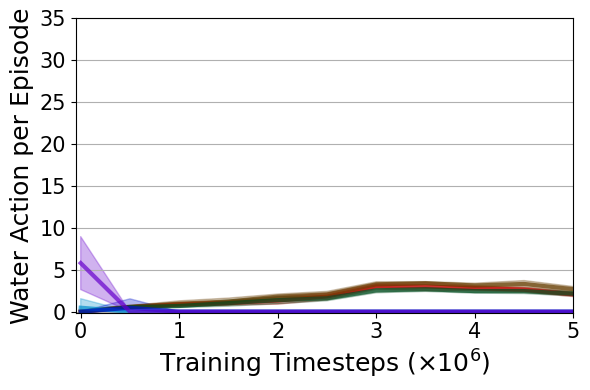

In [47]:
stasistic = np.load(cacti_log_dir + "/stasistic_all.npy", allow_pickle=True)[()]
n_checks = 15
timestep_clip = 5e6

fig = plt.figure(figsize=(6, 4))
count = 0
plt.xlabel(r"Training Timesteps $(\times10^6)$", fontsize=18)
plt.ylabel("Water Action per Episode", fontsize=18)

for key in stasistic:
    mean , conf= np.zeros(n_checks), np.zeros(n_checks)
    for i in range(n_checks):
        mean[i] = np.mean(stasistic[key][:, i, :])
        conf[i] = confidence_interval(np.mean(stasistic[key][:, i, :], 0))
    style = "solid" #if count < 3 else "--"
    plt.plot(np.arange(n_checks) * timesteps_freq, mean, lw=3, linestyle=style, c=dark_colors[count], alpha=0.7, label=key)
    plt.fill_between(np.arange(n_checks) * timesteps_freq, mean - conf, mean + conf, color=dark_colors[count], alpha=0.3)
    count += 1

x_legend = np.array(np.arange(0, n_checks + 1, 2) * 0.5, dtype=np.int8)
plt.xticks(np.arange(0, n_checks + 1, 2) * timesteps_freq, x_legend, fontsize=15)
plt.yticks(fontsize=15)
plt.grid(axis="y")
plt.xlim(-50000, timestep_clip)
plt.ylim(-0.1, 35)
plt.tight_layout()
# plt.savefig(cacti_main_dir + "frequency_water_short_line_style_no_legend.pdf", dpi=300)

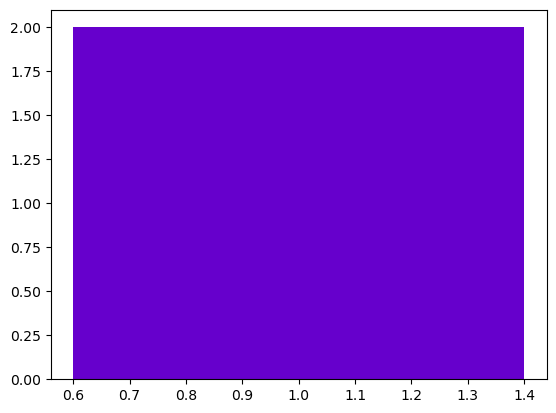

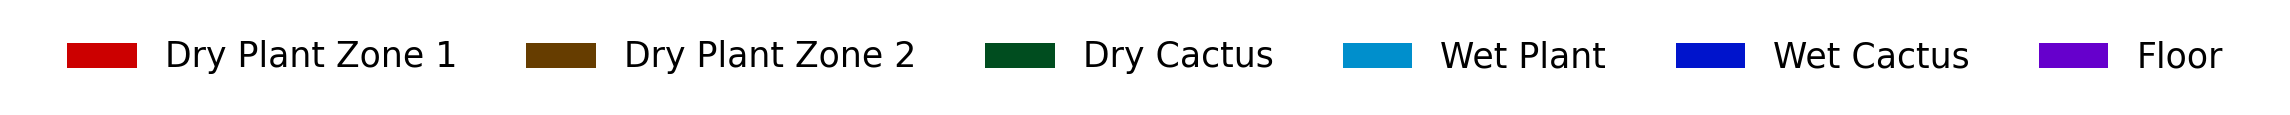

In [35]:
legends = ["Dry Plant Zone 1", "Dry Plant Zone 2", "Dry Cactus", "Wet Plant", "Wet Cactus", "Floor"]
f = lambda m,c: plt.bar(1,2, color=c)[0]
handles = [f("s", dark_colors[i]) for i in range(6)]
fig = plt.figure(figsize=(23, 1.25))
fig.legend(handles, legends, fontsize=25, ncol=6, loc='center', frameon=False)
fig.gca().set_axis_off()
plt.tight_layout()
# fig.savefig("../general_models/Plants/reward_model/10_10_channel/dry_0.05/cacti_room/window_11/" + "legend_horiz.pdf", dpi=300,)

## Baselines

In [18]:
timestep_clip = 10e6
fig = plt.figure(figsize=(6, 4))
count = 0
for base in ["reward_model", "zero_reward", "ignore"]:
    main_dir = "../general_models/Plants/{}/{}_{}_channel/dry_{}/cacti_room/window_{}/eps_decay_{}".format(
        base, n_rows, n_colums, dryness, window_size, 0.0001)
    log_dir = main_dir + "/q_lr_{}/reward_lr_{}/".format(q_lr, r_lr)
    seed_train, mean_train, _, conf_train = load_train_reward(log_dir)
    # for seed_tr in seed_train:
    #     plt.plot(np.arange(len(seed_tr)) * timesteps_freq, seed_tr, lw=0.5,  c=dark_colors[count])
    plt.plot(np.arange(len(mean_train)) * timesteps_freq, mean_train, lw=3,  c=dark_colors[count], alpha=0.7, label=base)
    plt.fill_between(np.arange(len(mean_train)) * timesteps_freq, mean_train - conf_train, mean_train + conf_train, color=dark_colors[count], alpha=0.3)
    count += 1


plt.xlabel(r"Training Timesteps $(\times 10^6)$", fontsize=18)
# plt.ylabel("Discounted Joint Reward", fontsize=18)

x_legend = np.arange(0, timestep_clip + 1e6, 2 * timesteps_freq) / 1e6
plt.xticks(np.arange(0, timestep_clip + 1e6, 2 * timesteps_freq), x_legend.astype(int), fontsize=15)
plt.xlim(-50000, timestep_clip)
plt.yticks(fontsize=15)
plt.grid(axis="y")
# plt.legend(fontsize=12)
plt.tight_layout()
dir = "../general_models/Plants/reward_model/10_10_channel/dry_0.05/cacti_room/window_11/eps_decay_0.0001/"
# fig.savefig(dir + "/room_training_curve_confidence_long.pdf", dpi=300)    

FileNotFoundError: [Errno 2] No such file or directory: '../general_models/Plants/reward_model/10_10_channel/dry_0.05/cacti_room/window_11/eps_decay_0.0001/q_lr_0.0001/reward_lr_0.0001/reward_train_all.npy'

<Figure size 600x400 with 0 Axes>

## 3-Rooms Monitor

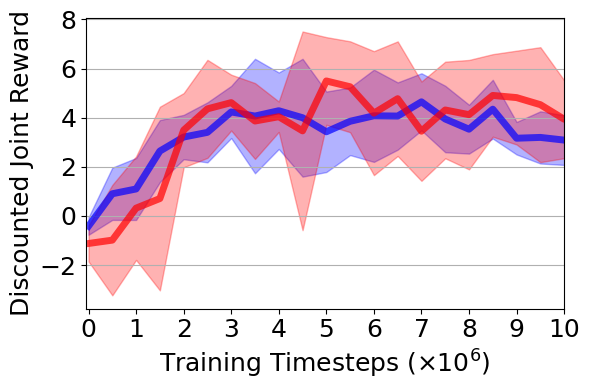

In [30]:
n_seeds = 10
ep_max_length = 100
ep_window = 10

timestep_clip = 10e6

discount = np.array([gamma**i for i in range(ep_max_length)])
room_3_dir = "../general_models/Plants/reward_model/{}_{}_channel/dry_{}/3_room/window_{}/eps_decay_0.0001/".format(
    n_rows, n_colums, dryness, window_size)
log_3_dir = room_3_dir + "/q_lr_{}/reward_lr_{}/".format(0.0001, 0.0001)

cut_indx = 5 if n_rows == 10 else 3
cut_indx_1 = int(cut_indx * 2)

fig = plt.figure(figsize=(6, 4))
one_seeds, two_seeds, three_seeds = [], [], []
for seed in range(n_seeds):
    agent_pos = np.load(log_3_dir + "/agent_locations_{}.npy".format(seed))
    train_reward = np.load(log_3_dir + "training_joint_reward_{}.npy".format(seed), allow_pickle=True)[()]
    reward_1, reward_2, reward_3 = [], [], []
    limit = min(list(train_reward.keys())[-1], len(agent_pos))
    for ep_train in range(limit):
    # for ep_train in range(len(agent_pos)):
        ones = np.squeeze(np.argwhere(agent_pos[ep_train, : , 1] < cut_indx))
        twos = np.squeeze(np.argwhere((agent_pos[ep_train, : , 1] > cut_indx) & (agent_pos[ep_train, : , 1] < cut_indx_1)))
    
        reward_1.append(np.sum(np.array(train_reward[ep_train])[ones] * discount[ones]))
        reward_2.append(np.sum(np.array(train_reward[ep_train])[twos] * discount[twos]))
    
    ep_length = ep_max_length * np.ones(len(train_reward))
    ep_timesteps_sum = sum_ep_timesteps(ep_length)
    x_axis = np.arange(ep_length[0], int(ep_timesteps_sum[-1]), timesteps_freq)
    y_axis_1, y_axis_2, y_axis_3 = [], [], []
    for timestep in range(int(ep_length[0]), int(ep_timesteps_sum[-1]), timesteps_freq):
        ind = np.where(ep_timesteps_sum > timestep)[0][0]
        value_1 = np.mean(reward_1[ind - ep_window: ind]) if ind > ep_window else reward_1[ind]
        value_2 = np.mean(reward_2[ind - ep_window: ind]) if ind > ep_window else reward_2[ind]

        y_axis_1.append(value_1)
        y_axis_2.append(value_2)

    one_seeds.append(y_axis_1)
    two_seeds.append(y_axis_2)
lenghts_1 = [len(l) for l in one_seeds]
lenghts_2 = [len(l) for l in two_seeds]

mean_1 = np.mean(np.array([l[:min(lenghts_1)] for l in one_seeds]), 0)
mean_2 = np.mean(np.array([l[:min(lenghts_2)] for l in two_seeds]), 0)

std_1 = confidence_interval_2d(np.array([l[:min(lenghts_1)] for l in one_seeds]))
std_2 = confidence_interval_2d(np.array([l[:min(lenghts_2)] for l in two_seeds]))

plt.plot(np.arange(len(mean_1)) * timesteps_freq, mean_1, lw=5,  c="b", alpha=0.7, label="Zone 1")
plt.fill_between(np.arange(len(mean_1)) * timesteps_freq, mean_1 - std_1, mean_1 + std_1, color="b", alpha=0.3)

plt.plot(np.arange(len(mean_2)) * timesteps_freq, mean_2, lw=5,  c="r", alpha=0.7, label="Zone 2")
plt.fill_between(np.arange(len(mean_2)) * timesteps_freq, mean_2 - std_2, mean_2 + std_2, color="r", alpha=0.3)

plt.xlabel(r"Training Timesteps ($\times10^{6}$)", fontsize=18)
plt.ylabel("Discounted Joint Reward", fontsize=18)

x_legend = np.arange(0, timestep_clip + 1e6, 2 * timesteps_freq) / 1e6
plt.xticks(np.arange(0, timestep_clip + 1e6, 2 * timesteps_freq), x_legend.astype(int), fontsize=15)
plt.yticks(fontsize=18) #18
plt.xticks(fontsize=18) #18
plt.xlim(-50000, timestep_clip)
plt.grid(axis="y")
plt.tight_layout()
# fig.savefig(room_3_dir + "training_reward_per_room_reward_cut_no_legend.pdf", dpi=300)

In [6]:
room_3_dir = "../general_models/Plants/reward_model/{}_{}_channel/dry_{}/3_room/window_{}/eps_decay_0.0001/".format(
    n_rows, n_colums, dryness, window_size)
log_3_dir = room_3_dir + "/q_lr_{}/reward_lr_{}/".format(0.0001, 0.0001)

n_ep = 1000
n_seeds = 20

stasistic = {
    "w_dry_plant_1" : np.zeros((n_seeds, n_ep)),
    "w_dry_plant_2" : np.zeros((n_seeds, n_ep)),
    "w_dry_cacti_1" : np.zeros((n_seeds, n_ep)),
    "w_dry_cacti_2" : np.zeros((n_seeds, n_ep)),
    "w_wet_plant": np.zeros((n_seeds, n_ep)),
    "w_wet_cacti": np.zeros((n_seeds, n_ep)),
    "w_diff_1": np.zeros((n_seeds, n_ep)),
    "w_diff_2": np.zeros((n_seeds, n_ep)),
    "w_diff_3": np.zeros((n_seeds, n_ep)),
    "w_diff_4": np.zeros((n_seeds, n_ep)),
    "w_diff_5": np.zeros((n_seeds, n_ep)),
    "w_floor": np.zeros((n_seeds, n_ep)),
}
for seed in range(n_seeds):
    q_model = torch.load(log_3_dir + "checkpoints_22/q_network_{}".format(seed + 10), map_location=torch.device(device))
    for episode in range(n_ep):
        floor, dry_cacti_1, dry_cacti_2, dry_plant_1, dry_plant_2, wet_plant, wet_cacti = 0, 0, 0, 0, 0, 0, 0
        diff_1, diff_2, diff_3, diff_4, diff_5 = 0, 0, 0, 0, 0
        s, _ = env.reset()
        total_r, timestep = 0, 0
        done = False
        # env.render()
        while timestep < 100 and not done:
            mdp_obs = torch.tensor(s["mdp"], dtype=torch.float32, device=device).unsqueeze(0)
            mon_obs = torch.tensor([s["monitor"]], dtype=torch.float32, device=device).unsqueeze(0)
            
            with torch.no_grad():
                q_values = q_model[5:](torch.concat((q_model[:5](mdp_obs), mon_obs), 1))
            action = select_action(q_values.cpu().numpy().squeeze())
            agent_pos =  env.get_agent_pos()
            plant = env.get_grid()[1, agent_pos[0], agent_pos[1]]
            dryness_level = s["mdp"][4, window_size // 2, window_size // 2]
            s, r, done, _, info = env.step({"mdp": action, "monitor": 0})
            if action == 4:
                if plant == 0.0:  # spill water in the floor
                    floor += 1
                elif plant == 0.5: # water cactus
                    if dryness_level == 0:
                        wet_cacti += 1
                    else:
                        if agent_pos[1] < 5:
                            dry_cacti_1 += 1
                        else:
                            dry_cacti_2 += 1
                elif plant == 1.0: # water Plant
                    if dryness_level == 0:
                        wet_plant += 1
                    else:
                        if agent_pos[1] < 5:
                            dry_plant_1 += 1
                        else:
                            dry_plant_2 += 1
                elif plant == 0.125: # water diff 1
                    diff_1 += 1
                elif plant == 0.25: # water diff 2
                    diff_2 += 1
                elif plant == 0.375: # water diff 3
                    diff_3 += 1
                elif plant == 0.625: # water diff 4
                    diff_4 += 1
                else:
                # elif plant == 0.875: # water diff 5
                    diff_5 += 1
            reward = info["mdp_reward"] + r["monitor"]
            total_r += reward * (gamma**timestep)
            timestep += 1
            # env.render()
        stasistic["w_dry_plant_1"][seed, episode] = dry_plant_1
        stasistic["w_dry_plant_2"][seed, episode] = dry_plant_2
        stasistic["w_dry_cacti_1"][seed, episode] = dry_cacti_1
        stasistic["w_dry_cacti_2"][seed, episode] = dry_cacti_2
        stasistic["w_wet_plant"][seed, episode] = wet_plant
        stasistic["w_wet_cacti"][seed, episode] = wet_cacti
        stasistic["w_diff_1"][seed, episode] = diff_1
        stasistic["w_diff_2"][seed, episode] = diff_2
        stasistic["w_diff_3"][seed, episode] = diff_3
        stasistic["w_diff_4"][seed, episode] = diff_4
        stasistic["w_diff_5"][seed, episode] = diff_5
        stasistic["w_floor"][seed, episode] = floor
    np.save(log_3_dir + "/stasistic_1.npy", stasistic)

/var/folders/wr/tm6dhxps7gnfznj02g89rcx40000gn/T/ipykernel_47723/2595105212.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  q_model = torch.load(log_3_dir + "checkpoint

In [5]:
room_3_dir = "../general_models/Plants/reward_model/{}_{}_channel/dry_{}/3_room/window_{}/eps_decay_0.0001/".format(
    n_rows, n_colums, dryness, window_size)
log_3_dir = room_3_dir + "/q_lr_{}/reward_lr_{}/".format(0.0001, 0.0001)

all_stat = np.load(log_3_dir + "/stasistic_all.npy", allow_pickle=True)[()]

In [6]:
n_seeds = 30
n_plants = {"w_diff_1": 0.8, "w_diff_2": 0.8, "w_diff_3": 0.8, "w_diff_4": 0.8, "w_diff_5": 0.8,
            "w_dry_plant_1": 4, "w_dry_plant_2": 4, "w_dry_cacti_1": 4, "w_dry_cacti_2": 4, "w_floor": 80}

to_plot = {
    "w_diff_1": [0, 0, 1], "w_diff_2": [0, 1, 0], "w_diff_3": [1, 0, 0], "w_diff_4": [1, 0, 1], "w_diff_5": [1, 1, 1],
    # "w_diff_1": [0, 0, 1], "w_diff_2": [0, 1, 0], "w_diff_4": [1, 0, 1],
    "w_dry_plant_1": "Plant Zone 1", "w_dry_plant_2": "Plant Zone 2",
    # "w_dry_cacti_1": "Cactus Zone 1", "w_dry_cacti_2": "Cactus Zone 2", "w_floor": "Floor",
}

x_labels = []
means, conf = np.zeros((len(to_plot))), np.zeros((len(to_plot)))
seeds_means = np.zeros((len(to_plot), n_seeds))
count = 0

count = 0
for key in to_plot:
    if key in ["w_dry_plant_1", "w_dry_plant_2"]:
        means[count] = np.mean(all_stat[key].reshape(-1)) / 1
    else:
        means[count] = np.mean(all_stat[key].reshape(-1)) / 1
    seeds_means[count] = np.mean(all_stat[key], 1)
    # means[count] = np.mean(all_stat[key].reshape(-1)) / n_plants[key]
    # conf[count] = confidence_interval(all_stat[key].reshape(-1))
    if key in ["w_dry_plant_1", "w_dry_plant_2"]:
        conf[count] = confidence_interval(np.mean(all_stat[key], 1) / 1)
    else:
        conf[count] = confidence_interval(np.mean(all_stat[key], 1) / 1)
    # conf[count] = confidence_interval(np.mean(stat[key], 1) / n_plants[key])
    count += 1

In [7]:
np.round(means, 2)

array([0.  , 0.01, 4.01, 0.  , 0.1 , 3.28, 4.13])

In [8]:
np.round(conf, 2)

array([0.  , 0.  , 3.75, 0.  , 0.05, 0.29, 0.36])

In [9]:
all_stat["w_floor"].shape

(30, 1000)